# Phase 2: Unsupervise Discovery (NER)

## set up

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import spacy
from spacy import displacy
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.decomposition import LatentDirichletAllocation

# Setup Thai font for matplotlib
!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

print("Setup complete. Libraries and models are ready.")

Setup complete. Libraries and models are ready.


In [2]:
%pip install pythainlp python-crfsuite

Note: you may need to restart the kernel to use updated packages.


## load dataset

The assignment said "ข้อมูลที่ Scrape มาใหม่"

In [3]:
from datasets import load_dataset

# thaipbs-news dataset (scraped)
tpbs_ds = load_dataset("szzs1693/nlp-thaipbs-news")

In [4]:
tpbs_df = tpbs_ds['train'].to_pandas()
tpbs_df.head()

,url,title,categoryName,abstract,publishedTime,tags,content_html,content_text
0,https://www.thaipbs.or.th/news/content/355884,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...",เศรษฐกิจ,,2025-09-01 03:38:00,"[อาร์เจนตินา, ส่งออกสินค้าไทย, ตลาดส่งออกไทย, ...","<p><strong><em>""บัวโนสไอเรส"" เมืองหลวงของอาร์เ...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่..."
1,https://www.thaipbs.or.th/news/content/356014,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,เศรษฐกิจ,,2025-09-02 04:43:00,"[เนื้อสุรินทร์, เนื้อโคขุน, เนื้อโค, โคขุน, จั...",<p><em><strong>“สีแดงอมชมพู ลายไขมันแทรกสวย” เ...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...
2,https://www.thaipbs.or.th/news/content/356017,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,เศรษฐกิจ,“รมว.เกษตรฯ” ถกบอร์ดไข่ไก่ ยันผู้ประกอบการขอนำ...,2025-09-01 08:40:00,"[ไข่ไก่, พ่อพันธุ์แม่พันธุ์ไก่, นำเข้าพ่อแม่พั...",<p>วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...
3,https://www.thaipbs.or.th/news/content/356047,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,เศรษฐกิจ,พาณิชย์ ถกรมว.อาเซียน-อินเดีย ดันทบทวนความตกลง...,2025-09-02 05:40:40,"[ความตกลงการค้าสินค้าอาเซียน–อินเดีย, อาเซียนอ...",<p>วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...
4,https://www.thaipbs.or.th/news/content/356067,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,เศรษฐกิจ,ข่าวดี สหรัฐฯ ประกาศ ไทยผ่านเกณฑ์มาตรฐาน MMPA ...,2025-09-02 08:59:13,"[กรมประมง, ส่งออกสัตว์น้ำ, สินค้าสัตว์น้ำไทย, ...",<p>วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบด...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...


## NER

In [5]:
from pythainlp.tag import NER
from spacy import displacy

ner = NER("thainer")

# Convert pythainlp NER output to displacy manual format for entity visualization
def to_spacy(ner_result):
    text_tokens = [token for token, _ in ner_result]
    full_text = "".join(text_tokens)

    entities = []
    current_entity = None
    char_index = 0

    for token, tag in ner_result:
        if tag.startswith("B-"):
            if current_entity: # If there was a previous entity that just ended
                current_entity["end"] = char_index
                entities.append(current_entity)

            entity_type = tag[2:] # Remove "B-"
            current_entity = {
                "start": char_index,
                "label": entity_type
            }
        elif tag.startswith("I-"):
            # Continue the current entity
            pass
        else: # tag == 'O'
            if current_entity: # If an entity just ended
                current_entity["end"] = char_index
                entities.append(current_entity)
                current_entity = None

        char_index += len(token)

    # Add the last entity if it hasn't been added
    if current_entity:
        current_entity["end"] = char_index
        entities.append(current_entity)

    return {
        "text": full_text,
        "ents": entities,
        "title": None
    }

In [6]:
from pythainlp.tokenize import sent_tokenize

def tokenize(text: str) -> str:
    sentences = sent_tokenize(text, engine="crfcut")
    return sentences

In [7]:
# # Custom text modifications
tpbs_df['text'] = tpbs_df['content_text']

tpbs_df['text'] = tpbs_df['text'].str.replace("ลาติมอเมริกา", "ลาตินอเมริกา")
tpbs_df['text'] = tpbs_df['text'].str.replace("ม.หอการค้าไทย", "มหาวิทยาลัยหอการค้าไทย")
tpbs_df['text'] = tpbs_df['text'].str.replace("ลบ.ม.", "ลูกบาตรเมตร")
tpbs_df['text'] = tpbs_df['text'].str.replace("พล.อ.", "พลเอก")
tpbs_df['text'] = tpbs_df['text'].str.replace("พ.อ.", "พันเอก")
tpbs_df['text'] = tpbs_df['text'].str.replace("ต.ค.", "ตุลาคม")

# Replace if not continued with space.
# "อ.เมือง" will be replaced, but not "อ. 2226"
tpbs_df['text'] = tpbs_df['text'].str.replace(r"จ\.(?! )", " จังหวัด", regex=True)
tpbs_df['text'] = tpbs_df['text'].str.replace(r"อ\.(?! )", " อำเภอ", regex=True)
tpbs_df['text'] = tpbs_df['text'].str.replace(r"ต\.(?! )", " ตำบล", regex=True)

In [8]:
sample_sentences = tokenize(tpbs_df['text'][12])
list(enumerate(sample_sentences))

[(0, 'เมื่อวันที่ 6 ก.ย.'),
 (1,
  '2568 หลังพรรคภูมิใจไทยเตรียมผลักดันโครงการคนละครึ่งในรูปแบบปรับปรุงใหม่ '),
 (2,
  'เพื่อเป็นมาตรการกระตุ้นเศรษฐกิจระยะสั้นทันทีหลังการแถลงนโยบายของรัฐบาล '),
 (3, 'โดยคาดว่าจะเริ่มดำเนินการได้ภายในเดือนแรกหลังการแถลง '),
 (4, 'นายสิริพงศ์ อังคสกุลเกียรติ รองหัวหน้าพรรคภูมิใจไทย '),
 (5, 'เปิดเผยว่า ทีมเศรษฐกิจของพรรคได้หารือถึงแนวทางการฟื้นฟูเศรษฐกิจ '),
 (6,
  'โดยหนึ่งในนั้นคือการนำโครงการคนละครึ่งกลับมาใช้ในรูปแบบที่อัพเกรดจากเดิม '),
 (7, 'เพิ่มสิทธิประโยชน์ให้ประชาชนและร้านค้า '),
 (8,
  'ด้วยการใช้ระบบเดิมที่มีอยู่เพื่อให้เริ่มใช้งานได้ทันที\nอ่านข่าว : "สิริพงศ์" '),
 (9, 'รับจ่อฟื้นนโยบายคนละครึ่ง '),
 (10,
  'หวังกระตุ้นเศรษฐกิจระยะสั้น\nจากการสำรวจของทีมข่าวไทยพีบีเอสที่ตลาดบ้านหนองคอก  อำเภอท่าตะเกียบ  จังหวัดฉะเชิงเทรา '),
 (11,
  'พบว่าร้านค้าชุมชนบ้านเกาะลอยและพ่อค้าแม่ค้าต่างตื่นเต้นกับข่าวการฟื้นฟูโครงการคนละครึ่ง '),
 (12, 'นายพัชร์บท ตั้งมา '),
 (13,
  'เจ้าของร้านค้าชุมชนบ้านเกาะลอย ระบุว่าในช่วงที่มีโครงการคนละครึ่งสมัยรัฐบาล พลเ

In [9]:
# Visualize NER results for all sentences in the first sample entry
print("Visualizing NER results for all sentences in sample record:")
for i, sentence in enumerate(sample_sentences[0:10]):
    print(f"Sentence {i+1}:")
    ner_sentence_result = ner.tag(sentence)
    displacy.render(to_spacy(ner_sentence_result), style="ent", manual=True, jupyter=True)

Visualizing NER results for all sentences in sample record:
Sentence 1:


Sentence 2:


Sentence 3:


Sentence 4:


Sentence 5:


Sentence 6:


Sentence 7:


Sentence 8:


Sentence 9:


Sentence 10:


In [10]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing Sentences")
tpbs_df["sentences"] = tpbs_df["text"].progress_apply(tokenize)

Tokenizing Sentences: 100%|█████████████████| 1200/1200 [00:19<00:00, 60.49it/s]


In [11]:
# Number of sentences across all articles
tpbs_df["sentences"].str.len().describe()

count    1200.000000
mean       34.884167
std        23.358734
min         5.000000
25%        19.000000
50%        29.000000
75%        44.000000
max       212.000000
Name: sentences, dtype: float64

## Perform NER on Sentences

In [12]:
def process_sentences_for_ner(sentence_list):
    """
    Applies NER to each sentence in a list of sentences.
    """
    ner_results = []
    for sentence in sentence_list:
        ner_results.append(ner.tag(sentence))
    return ner_results

# Apply the function to the 'sentences' column and store the results in 'ner_sentences'
tqdm.pandas(desc='NER')
tpbs_df["ner_sentences"] = tpbs_df["sentences"].progress_apply(process_sentences_for_ner)

NER: 100%|██████████████████████████████████| 1200/1200 [00:29<00:00, 40.94it/s]


## Entity Extraction & Aggregation

In [13]:
def extract_entities(ner_sentences):
    """Extract all named entities from a list of NER-tagged sentences."""
    entities = []
    for sentence in ner_sentences:
        current_tokens = []
        current_type = None
        for token, tag in sentence:
            if tag.startswith("B-"):
                if current_tokens:
                    entities.append(("".join(current_tokens), current_type))
                current_tokens = [token]
                current_type = tag[2:]
            elif tag.startswith("I-") and current_tokens:
                current_tokens.append(token)
            else:
                if current_tokens:
                    entities.append(("".join(current_tokens), current_type))
                    current_tokens = []
                    current_type = None
        if current_tokens:
            entities.append(("".join(current_tokens), current_type))
    return entities

# Build a flat DataFrame of all entities with their source article's category
records = []
for _, row in tpbs_df.iterrows():
    for entity_text, entity_type in extract_entities(row["ner_sentences"]):
        records.append({
            "entity": entity_text,
            "entity_type": entity_type,
            "category": row["categoryName"],
        })

entities_df = pd.DataFrame(records)
print(f"Total entity mentions: {len(entities_df):,}")
print(f"Unique entities: {entities_df['entity'].nunique():,}")
print(f"\nEntity type counts:")
print(entities_df["entity_type"].value_counts())

Total entity mentions: 38,025
Unique entities: 13,579

Entity type counts:
entity_type
LOCATION        11119
ORGANIZATION     7750
PERSON           6770
DATE             4247
MONEY            2636
TIME             2424
PERCENT          2224
LAW               536
LEN               157
URL               128
ZIP                31
EMAIL               2
PHONE               1
Name: count, dtype: int64


## Entity Type Distribution

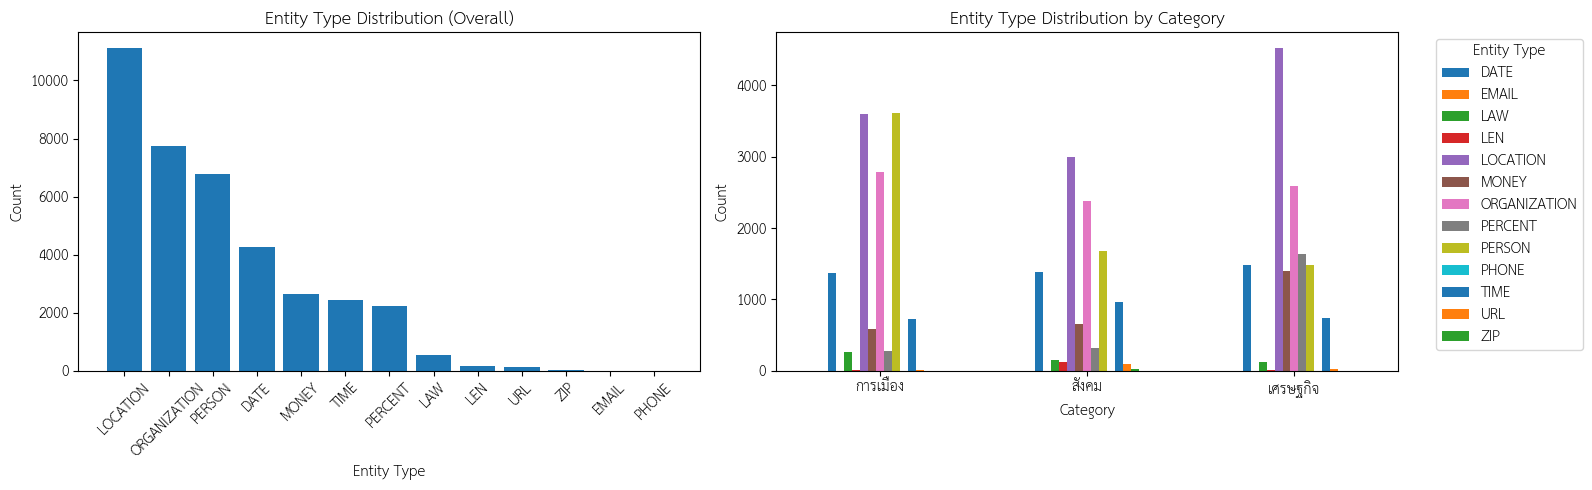

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall entity type distribution
type_counts = entities_df["entity_type"].value_counts()
axes[0].bar(type_counts.index, type_counts.values)
axes[0].set_title("Entity Type Distribution (Overall)")
axes[0].set_xlabel("Entity Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Entity type distribution per category
cat_type = entities_df.groupby(["category", "entity_type"]).size().unstack(fill_value=0)
cat_type.plot(kind="bar", ax=axes[1])
axes[1].set_title("Entity Type Distribution by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Entity Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Top Entities per Type

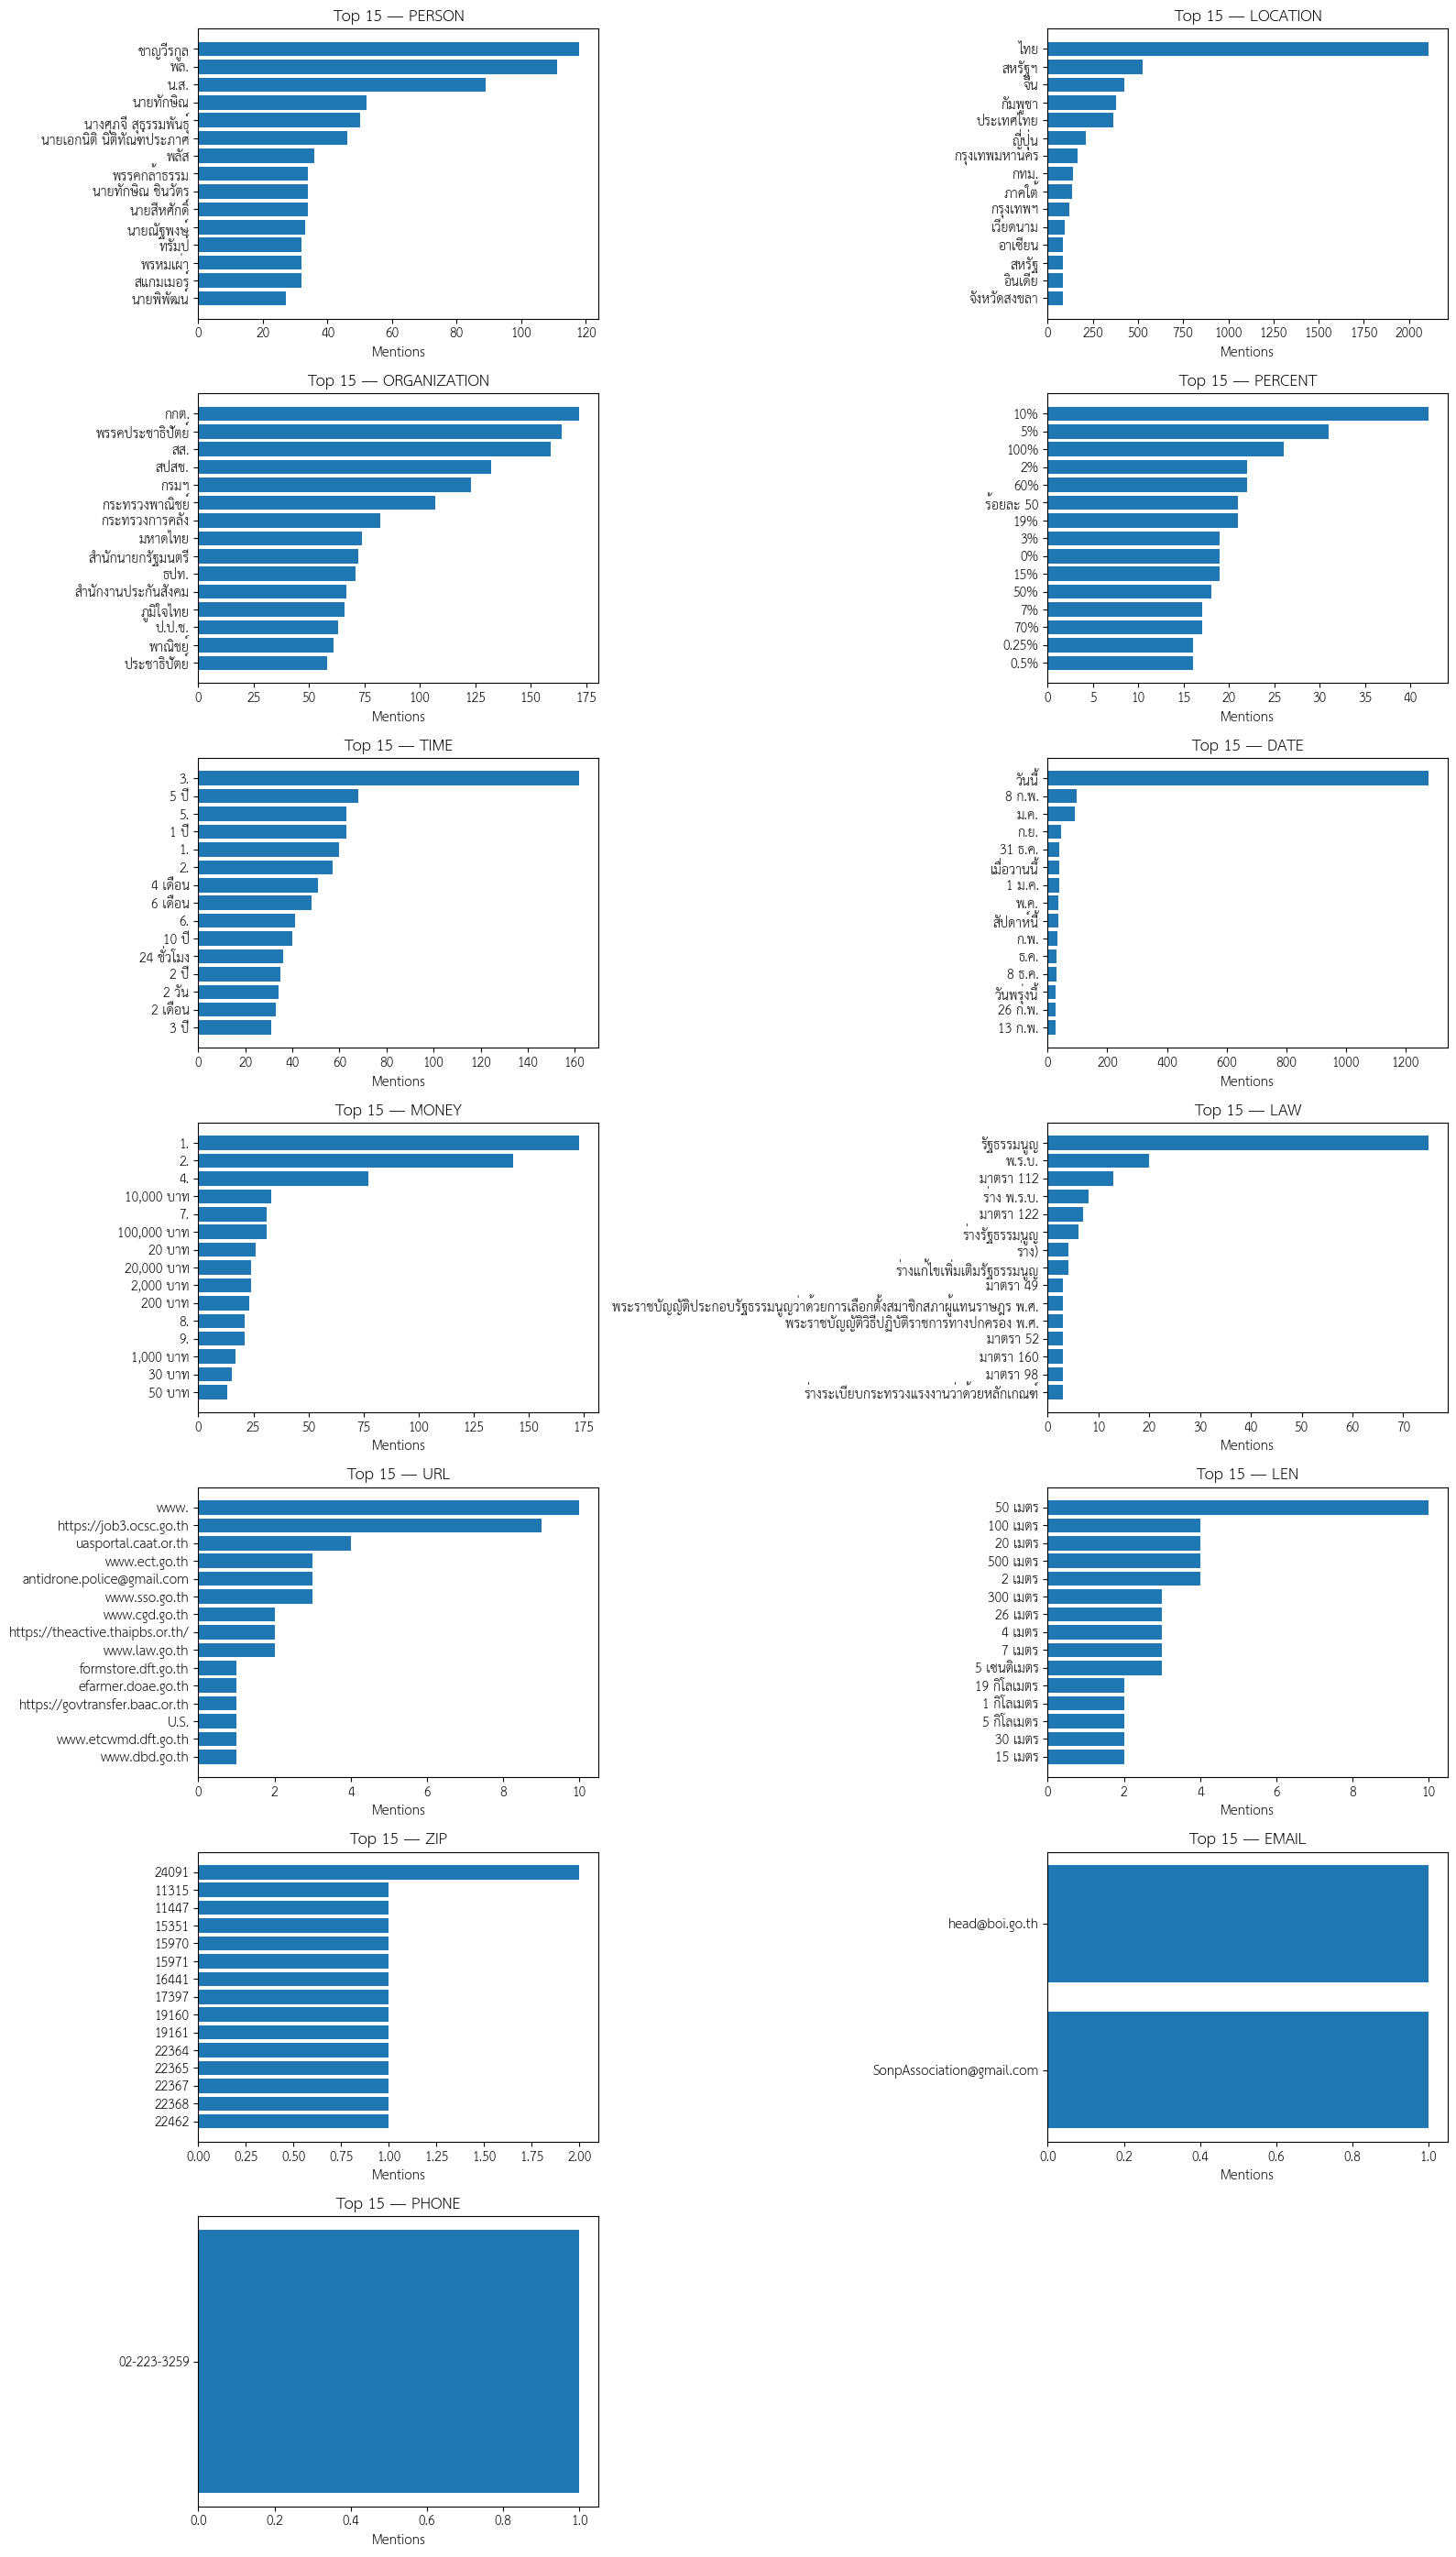

In [15]:
TOP_N = 15
entity_types = entities_df["entity_type"].unique()
ncols = 2
nrows = -(-len(entity_types) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for ax, etype in zip(axes, entity_types):
    top = (
        entities_df[entities_df["entity_type"] == etype]["entity"]
        .value_counts()
        .head(TOP_N)
    )
    ax.barh(top.index[::-1], top.values[::-1])
    ax.set_title(f"Top {TOP_N} — {etype}")
    ax.set_xlabel("Mentions")

# Hide unused subplots
for ax in axes[len(entity_types):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Inspect Articles by Entity Token

In [16]:
# Set the token and optional entity type to inspect
INSPECT_TOKEN = "จ."
INSPECT_TYPE = None  # Set to e.g. "LOCATION" to filter by type, or None for any type

mask = entities_df["entity"] == INSPECT_TOKEN
if INSPECT_TYPE:
    mask &= entities_df["entity_type"] == INSPECT_TYPE

matched = entities_df[mask]
print(f"'{INSPECT_TOKEN}' appears {len(matched):,} times across {matched.index.nunique():,} mentions")
print(f"\nEntity type breakdown:")
print(matched["entity_type"].value_counts())
print(f"\nCategory breakdown:")
print(matched["category"].value_counts())

# Find source articles that contain this entity
article_indices = []
for idx, row in tpbs_df.iterrows():
    for entity_text, entity_type in extract_entities(row["ner_sentences"]):
        if entity_text == INSPECT_TOKEN and (INSPECT_TYPE is None or entity_type == INSPECT_TYPE):
            article_indices.append(idx)
            break

print(f"\nFound in {len(article_indices)} articles. Showing first 5:\n")
for idx in article_indices[:5]:
    row = tpbs_df.iloc[idx]
    print(f"[Index {idx}, {row['categoryName']}] {row['title']}\n")
    sentences = row["sentences"]
    # Show sentences containing the token
    for i, sentence in enumerate(sentences):
        if INSPECT_TOKEN in sentence:
            if i > 0:
                print(f"    ... {repr(sentences[i - 1][:120])}")
            print(f"[{i:>02}]  > {repr(sentence[:120])}")
            for j in range(i + 1, min(i + 3, len(sentences))):
                print(f"    ... {repr(sentences[j][:120])}")
            print()
    print()

'จ.' appears 8 times across 8 mentions

Entity type breakdown:
entity_type
LOCATION    8
Name: count, dtype: int64

Category breakdown:
category
การเมือง    4
เศรษฐกิจ    2
สังคม       2
Name: count, dtype: int64

Found in 8 articles. Showing first 5:

[Index 295, เศรษฐกิจ] “กาแฟ GI” ครองใจนักดื่ม ปี68 สร้างยอดขาย1.49 พันล้าน  ตอกย้ำเอกลักษณ์กาแฟไทย 

    ... 'เปิดเผยว่า ปัจจุบันประเทศไทยมีการขึ้นทะเบียนสิ่งบ่งชี้ทางภูมิศาสตร์ (GI) ในกลุ่มสินค้า กาแฟ รวมทั้งสิ้น 11 รายการ จาก 8 '
[05]  > 'และกาแฟดอยช้าง ของจ.'
    ... ' เชียงราย) กาแฟเทพเสด็จ  จังหวัดเชียงใหม่ '
    ... 'กาแฟดอยสวนยาหลวงน่าน '


[Index 399, เศรษฐกิจ] "มะพร้าวน้ำหอม" สะเทือน "ทุนเทารุกคืบ-ราคาดิ่ง" กระทบเศรษฐกิจฐานราก

    ... 'ตรวจสอบล้งมะพร้าว 3 แห่ง และบริษัทที่อาจมีลักษณะเข้าข่ายนอมินี 4 แห่ง รวมทั้งตรวจสอบบริษัทกลุ่มเสี่ยงที่มีชาวต่างชาติร่ว'
[42]  > 'ไม่ถึง 50% (ยังคงมีสถานะเป็นไทย) 217 บริษัท ของ  จังหวัดราชบุรี และตรวจสอบการถือครองที่ดิน ตั้งแต่ 5 ไร่ขึ้นไปใน จ.'
    ... ' ราชบุรีและสมุทรสาคร\n\nทั้งนี้ พบว่ามีบ